fraud_covid_analysis

In [1]:
import sys
!python.exe -m pip install --upgrade pip

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

Loading Dataset

In [14]:
df = pd.read_csv("C:/Users/hp/OneDrive/Desktop/Project github/fraud_covid_analysis_data.csv")

Data Cleaning

In [15]:
df.head(10)

,Date,Daily_Cases,Daily_Deaths,Recoveries,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Location,Device_Type,Is_Fraud
0,2020-01-01,16088,1872,44466,T0,24320,4524.77,POS,UK,Desktop,1
1,2020-01-02,32098,1727,13632,T1,323431,3311.10,ATM,USA,Mobile,0
2,2020-01-03,13857,1806,35181,T2,924991,4192.95,ATM,UK,Desktop,0
3,2020-01-04,11959,1436,41599,T3,751744,6534.64,ATM,UK,Tablet,1
4,2020-01-05,561,1378,9160,T4,420333,5566.56,POS,UK,Tablet,1
5,2020-01-06,6676,1184,17030,T5,842799,6223.53,POS,Australia,Desktop,1
6,2020-01-07,41939,936,21307,T6,293582,8191.39,POS,UK,Desktop,0
7,2020-01-08,4303,338,14177,T7,370760,211.94,Transfer,Canada,Mobile,1
8,2020-01-09,6336,2000,1295,T8,576653,2088.46,POS,Australia,Mobile,0
9,2020-01-10,14394,72,25868,T9,911937,8336.17,ATM,India,Desktop,0


In [16]:
df.tail()

,Date,Daily_Cases,Daily_Deaths,Recoveries,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Location,Device_Type,Is_Fraud
79995,2022-09-22,12488,342,5953,T79995,938672,2668.66,ATM,USA,Desktop,0
79996,2022-09-23,3472,927,10684,T79996,286376,2289.76,Online,UK,Tablet,1
79997,2022-09-24,5433,1293,44591,T79997,80723,2147.80,Transfer,USA,Tablet,1
79998,2022-09-25,48118,1329,21681,T79998,456235,2076.35,ATM,UK,Tablet,1
79999,2022-09-26,48205,1914,7282,T79999,830171,6024.71,Transfer,UK,Mobile,1


In [17]:
df.shape

(80000, 11)

In [18]:
df.columns

Index(['Date', 'Daily_Cases', 'Daily_Deaths', 'Recoveries', 'Transaction_ID',
       'User_ID', 'Transaction_Amount', 'Transaction_Type', 'Location',
       'Device_Type', 'Is_Fraud'],
      dtype='str')

Exploratory Data Analysis

In [19]:
df.sum()

Date                  2020-01-012020-01-022020-01-032020-01-042020-0...
Daily_Cases                                                  2005900189
Daily_Deaths                                                   80004344
Recoveries                                                   1926262842
Transaction_ID        T0T1T2T3T4T5T6T7T8T9T10T11T12T13T14T15T16T17T1...
User_ID                                                     40045592246
Transaction_Amount                                         400147240.93
Transaction_Type      POSATMATMATMPOSPOSPOSTransferPOSATMTransferATM...
Location              UKUSAUKUKUKAustraliaUKCanadaAustraliaIndiaUKUK...
Device_Type           DesktopMobileDesktopTabletTabletDesktopDesktop...
Is_Fraud                                                          40071
dtype: object

In [20]:
df.isnull().sum()

Date                  0
Daily_Cases           0
Daily_Deaths          0
Recoveries            0
Transaction_ID        0
User_ID               0
Transaction_Amount    0
Transaction_Type      0
Location              0
Device_Type           0
Is_Fraud              0
dtype: int64

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                80000 non-null  str    
 1   Daily_Cases         80000 non-null  int64  
 2   Daily_Deaths        80000 non-null  int64  
 3   Recoveries          80000 non-null  int64  
 4   Transaction_ID      80000 non-null  str    
 5   User_ID             80000 non-null  int64  
 6   Transaction_Amount  80000 non-null  float64
 7   Transaction_Type    80000 non-null  str    
 8   Location            80000 non-null  str    
 9   Device_Type         80000 non-null  str    
 10  Is_Fraud            80000 non-null  int64  
dtypes: float64(1), int64(5), str(5)
memory usage: 9.2 MB


In [22]:
df.describe()

,Daily_Cases,Daily_Deaths,Recoveries,User_ID,Transaction_Amount,Is_Fraud
count,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000
mean,25073.752362,1000.054300,24078.285525,500569.903075,5001.840512,0.500888
std,14419.196441,578.348262,13891.953047,288035.268563,2887.595491,0.500002
min,0.000000,0.000000,0.000000,1007.000000,1.050000,0.000000
25%,12596.750000,501.000000,12025.000000,251690.750000,2502.055000,0.000000
50%,25075.000000,998.000000,24146.500000,500579.000000,5016.725000,1.000000
75%,37553.250000,1499.000000,36150.000000,750133.250000,7498.402500,1.000000
max,50000.000000,2000.000000,48000.000000,999896.000000,9999.860000,1.000000


In [23]:
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns


In [26]:
# -------------------------
# LOAD DATA
# -------------------------
df = pd.read_csv("C:/Users/hp/OneDrive/Desktop/Project github/fraud_covid_analysis_data.csv")

In [31]:
# Drop missing dates
df = df.dropna(subset=["Date"])



In [32]:
# Drop missing dates
df = df.dropna(subset=["Date"])


In [33]:
# Basic info
print(df.head())
print(df.info())

        Date  Daily_Cases  Daily_Deaths  Recoveries Transaction_ID  User_ID  \
0 2020-01-01        16088          1872       44466             T0    24320   
1 2020-01-02        32098          1727       13632             T1   323431   
2 2020-01-03        13857          1806       35181             T2   924991   
3 2020-01-04        11959          1436       41599             T3   751744   
4 2020-01-05          561          1378        9160             T4   420333   

   Transaction_Amount Transaction_Type Location Device_Type  Is_Fraud  
0             4524.77              POS       UK     Desktop         1  
1             3311.10              ATM      USA      Mobile         0  
2             4192.95              ATM       UK     Desktop         0  
3             6534.64              ATM       UK      Tablet         1  
4             5566.56              POS       UK      Tablet         1  
<class 'pandas.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 11 colum

In [34]:
# -------------------------
# KPI INSIGHTS
# -------------------------
print("Total Cases:", df["Daily_Cases"].sum())
print("Total Deaths:", df["Daily_Deaths"].sum())
print("Total Recoveries:", df["Recoveries"].sum())
print("Total Transaction Amount:", df["Transaction_Amount"].sum())
print("Fraud Transactions:", df["Is_Fraud"].sum())


Total Cases: 2005900189
Total Deaths: 80004344
Total Recoveries: 1926262842
Total Transaction Amount: 400147240.93
Fraud Transactions: 40071


In [35]:
# Set style
sns.set(style="whitegrid")


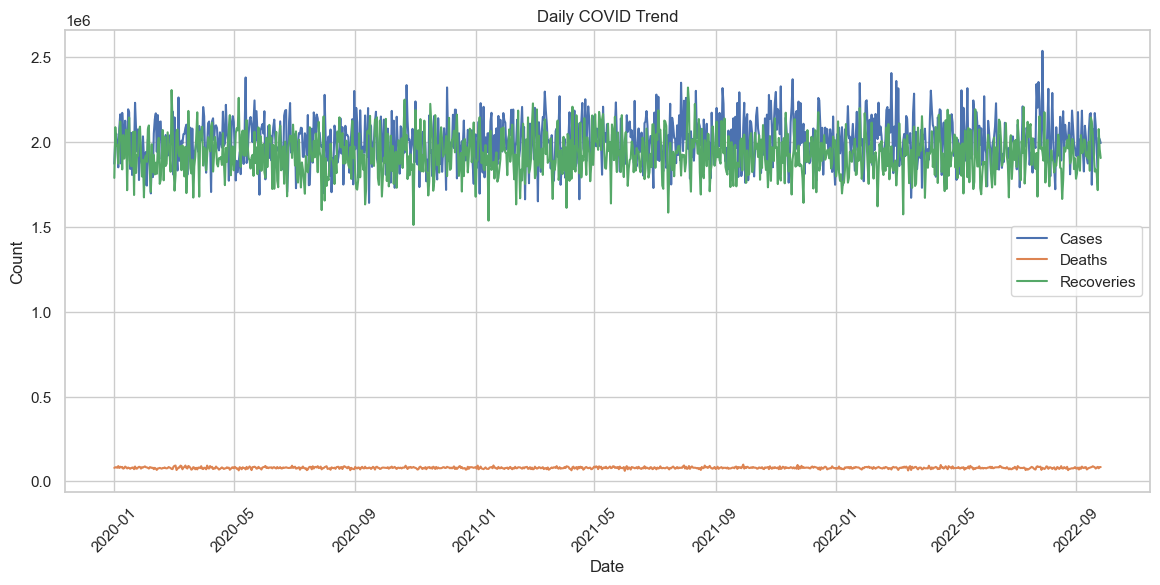

In [36]:
# -------------------------
# 1. DAILY COVID TREND (MATPLOTLIB)
# -------------------------
daily = df.groupby("Date")[["Daily_Cases", "Daily_Deaths", "Recoveries"]].sum()

plt.figure(figsize=(14,6))
plt.plot(daily.index, daily["Daily_Cases"], label="Cases")
plt.plot(daily.index, daily["Daily_Deaths"], label="Deaths")
plt.plot(daily.index, daily["Recoveries"], label="Recoveries")
plt.title("Daily COVID Trend")
plt.xlabel("Date")
plt.ylabel("Count")
plt.legend()
plt.xticks(rotation=45)
plt.show()

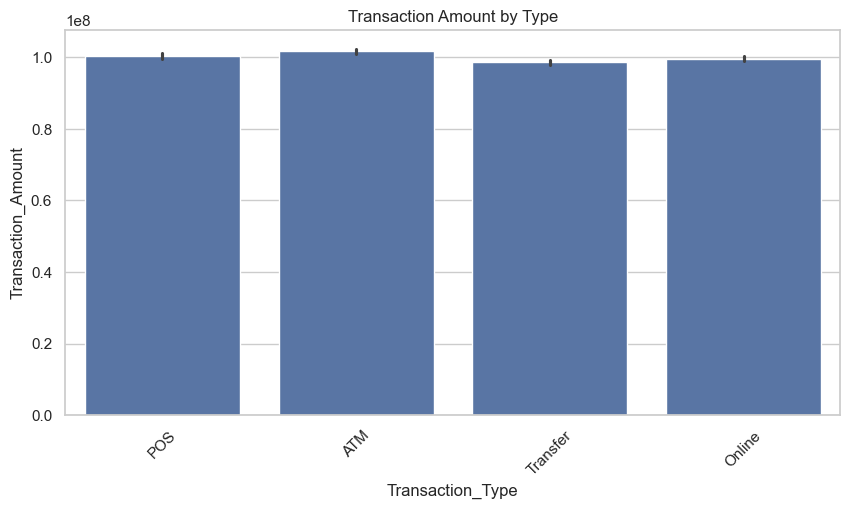

In [37]:
# -------------------------
# 2. TRANSACTION TYPE ANALYSIS (SEABORN)
# -------------------------
plt.figure(figsize=(10,5))
sns.barplot(
    data=df,
    x="Transaction_Type",
    y="Transaction_Amount",
    estimator=sum
)
plt.title("Transaction Amount by Type")
plt.xticks(rotation=45)
plt.show()


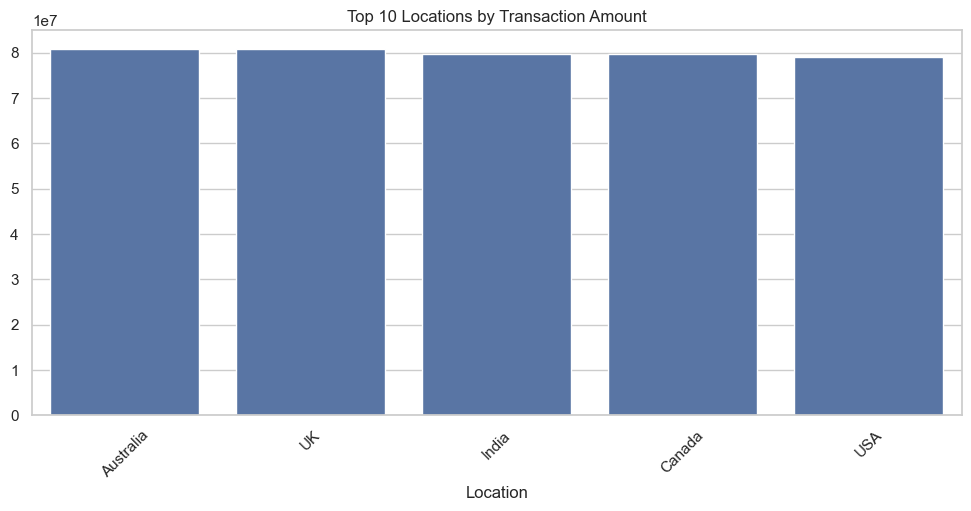

In [39]:
# -------------------------
# 3. LOCATION ANALYSIS (SEABORN)
# -------------------------
location_data = (
    df.groupby("Location")["Transaction_Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,5))
sns.barplot(
    x=location_data.index,
    y=location_data.values
)
plt.title("Top 10 Locations by Transaction Amount")
plt.xticks(rotation=45)
plt.show()

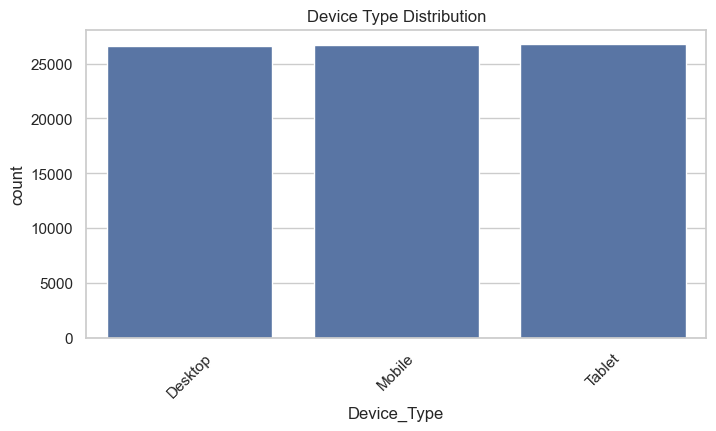

In [40]:
# -------------------------
# 4. DEVICE TYPE DISTRIBUTION (SEABORN)
# -------------------------
plt.figure(figsize=(8,4))
sns.countplot(data=df, x="Device_Type")
plt.title("Device Type Distribution")
plt.xticks(rotation=45)
plt.show()

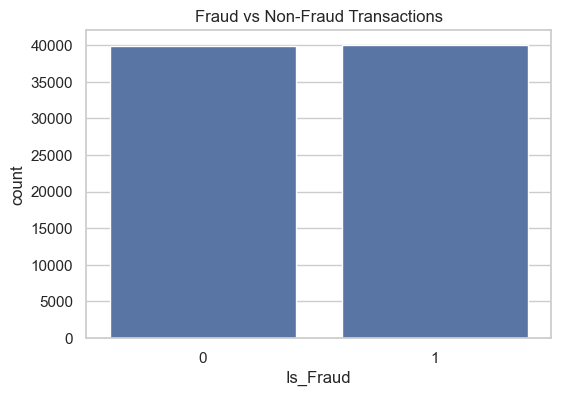

In [41]:
# -------------------------
# 5. FRAUD VS NON-FRAUD (SEABORN)
# -------------------------
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Is_Fraud")
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()

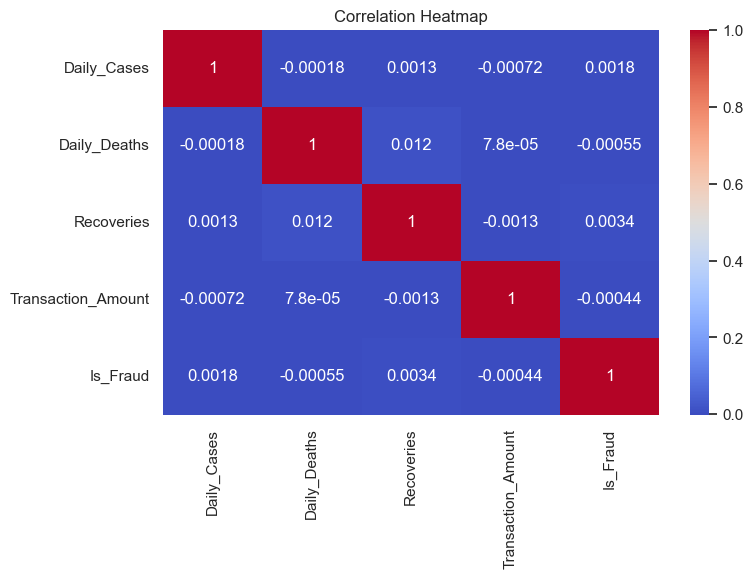

In [42]:
# -------------------------
# 6. CORRELATION HEATMAP (SEABORN)
# -------------------------
plt.figure(figsize=(8,5))
sns.heatmap(
    df[["Daily_Cases", "Daily_Deaths", "Recoveries", "Transaction_Amount", "Is_Fraud"]].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

In [43]:
# -------------------------
# 7. INTERACTIVE PLOTLY TREND
# -------------------------
fig = px.line(
    daily.reset_index(),
    x="Date",
    y=["Daily_Cases", "Daily_Deaths", "Recoveries"],
    title="Interactive COVID Trend"
)
fig.show()

In [44]:
# -------------------------
# 8. INTERACTIVE FRAUD BY LOCATION
# -------------------------
fraud_location = (
    df.groupby("Location")["Is_Fraud"]
    .sum()
    .reset_index()
    .sort_values("Is_Fraud", ascending=False)
)

fig2 = px.bar(
    fraud_location,
    x="Location",
    y="Is_Fraud",
    title="Fraud Transactions by Location"
)
fig2.show()